# Pharmacogenomics Machine Learning Project
## Notebook 01: Data Exploration

### Purpose
This notebook exlores the ClinPGx datasets that will be used to build a pharmacogenomics machine learning model.

The objects of this notebook are to:
- Understand the structure of each dataset
- Identify potential merge keys
- Examine data quality
- Document missing values
- Identify duplicate records
- Understand relationships between datasets

This notebook is exploratory only.
No data cleaning or modification will be performed here.

### 1. Import Libraries

In [175]:
# Import the pandas library for reading, manipulating, and analyzing tabular data.
import pandas as pd

# Import NumPy for numerical operations.
import numpy as np

# Import Matplotlib for creating graphs and visualizations.
import matplotlib.pyplot as plt

# Import Path from pathlib to build operating system-independent file paths.
from pathlib import Path


### 2. Configure Display Settings

In [176]:
# Display every column in a DataFrame instead of truncating wide tables.
pd.set_option("display.max_columns", None)

# Allow up to 100 rows to be displayed before truncation for more context when examning datasets.
pd.set_option("display.max_rows", 100)

# Set a consistent default figure size for all plots in this notebook.
plt.rcParams["figure.figsize"] = (10, 6)

### 3. Define Data Paths

In [177]:
# Create a Path object that points to the folder containing the raw ClinPGx datasets.
DATA_PATH = Path("../data/raw")

# Create file paths for each ClinPGx dataset.
clinical_file = DATA_PATH / "clinicalVariants.tsv"
drug_file = DATA_PATH / "var_drug_ann.tsv"
phenotype_file = DATA_PATH / "var_pheno_ann.tsv"
functional_file = DATA_PATH / "var_fa_ann.tsv"

### 4. Load Datasets

In [178]:
# Read the Clinical Variants dataset into a pandas DataFrame.
clinical = pd.read_csv(clinical_file, sep="\t")

# Read the Variant Drug Annotation dataset.
drug = pd.read_csv(drug_file, sep="\t")

# Read the Variant Phenotype Annotation dataset.
phenotype = pd.read_csv(phenotype_file, sep="\t")

# Read the Functional Assay Annotation dataset.
functional = pd.read_csv(functional_file, sep="\t")

In [179]:
# Print the dimensions of each dataset: (number of rows, number of columns)
print("Clinical:", clinical.shape)
print("Drug:", drug.shape)
print("Phenotype:", phenotype.shape)
print("Functional:", functional.shape)

Clinical: (5190, 6)
Drug: (12975, 22)
Phenotype: (14490, 25)
Functional: (2153, 23)


### 5. Dataset Summary
&emsp;This information helps determine whether any columns may require cleaning later.\
&emsp;This includes:\
&emsp;&ensp;- number of rows\
&emsp;&ensp;- number of columns\
&emsp;&ensp;- column names\
&emsp;&ensp;- data types\
&emsp;&ensp;- number of non-missing values

In [180]:
# Display summary information about the Clinical Variants dataset.
clinical.info()

<class 'pandas.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   variant            5190 non-null   str  
 1   gene               4936 non-null   str  
 2   type               5190 non-null   str  
 3   level of evidence  5190 non-null   str  
 4   chemicals          5190 non-null   str  
 5   phenotypes         4175 non-null   str  
dtypes: str(6)
memory usage: 243.4 KB


In [181]:
# Display summary information for the Variant Drug Annotation dataset.
drug.info()

<class 'pandas.DataFrame'>
RangeIndex: 12975 entries, 0 to 12974
Data columns (total 22 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   Variant Annotation ID                   12975 non-null  int64
 1   Variant/Haplotypes                      12975 non-null  str  
 2   Gene                                    12635 non-null  str  
 3   Drug(s)                                 12975 non-null  str  
 4   PMID                                    12975 non-null  int64
 5   Phenotype Category                      12951 non-null  str  
 6   Significance                            12975 non-null  str  
 7   Notes                                   11340 non-null  str  
 8   Sentence                                12975 non-null  str  
 9   Alleles                                 12436 non-null  str  
 10  Specialty Population                    1339 non-null   str  
 11  Metabolizer types         

In [182]:
# Display summary information for the Variant Phenotype Annotation dataset.
phenotype.info()

<class 'pandas.DataFrame'>
RangeIndex: 14490 entries, 0 to 14489
Data columns (total 25 columns):
 #   Column                                          Non-Null Count  Dtype
---  ------                                          --------------  -----
 0   Variant Annotation ID                           14490 non-null  int64
 1   Variant/Haplotypes                              14490 non-null  str  
 2   Gene                                            14074 non-null  str  
 3   Drug(s)                                         13551 non-null  str  
 4   PMID                                            14490 non-null  int64
 5   Phenotype Category                              14358 non-null  str  
 6   Significance                                    14490 non-null  str  
 7   Notes                                           11762 non-null  str  
 8   Sentence                                        14490 non-null  str  
 9   Alleles                                         14005 non-null  str  
 1

In [183]:
# Display summary information for the Functional Assay dataset.
functional.info()

<class 'pandas.DataFrame'>
RangeIndex: 2153 entries, 0 to 2152
Data columns (total 23 columns):
 #   Column                                          Non-Null Count  Dtype
---  ------                                          --------------  -----
 0   Variant Annotation ID                           2153 non-null   int64
 1   Variant/Haplotypes                              2153 non-null   str  
 2   Gene                                            2103 non-null   str  
 3   Drug(s)                                         1488 non-null   str  
 4   PMID                                            2153 non-null   int64
 5   Phenotype Category                              2005 non-null   str  
 6   Significance                                    2153 non-null   str  
 7   Notes                                           1961 non-null   str  
 8   Sentence                                        2153 non-null   str  
 9   Alleles                                         2146 non-null   str  
 10 

#### Observations

&emsp;The Clinical Variants dataset contains 5,190 records and 6 columns, making it the most concise of the four ClinPGx datasets. Rather than storing detailed study information, it summarizes clinicaly important gene-drug relationships and their associated evidence levels. Because this dataset is highly curated, it is likely to serve as the primary source of clinically relevant labels for the machine learning model. However, its limited number of features suggests that it will need to be supplemented with information from the other ClinPGx datasets to create a richer feature set.

&emsp;The Variant Drug Annotation dataset contains substantially more records and many more descriptive columns than the Clinical Variants dataset. The additional information includes publication identifiers, phenotype categories, significance values, metabolizer classifications, and population information. This dataset appears to provide the detailed scientific evidence underlying many of the summarized clinical relationships. These variables may become useful predictive features after careful preprocessing and standardization. Because this dataset contains considerably more metadata, it is expected to require more extensive cleaning than the Clinical Variants dataset.

&emsp; The Variant Phenotype Annotation dataset is the largest of the four datasets. It contains detailed descriptions of observed phenotypic outcomes associated with genetic variants and drug exposure. The larger number of observations suggests that individual gene-drug relationships may appear multiple times across different studies or populations. These repeated observations are expected and should not automatically be interpreted as duplicate errors. Instead, repeated evidence may later be aggregated into summary features such as the number of supporting studies or the consistency of reported outcomes.

&emsp; The Functional Assay dataset contains laboratory-based evidence describing how genetic variants influence biological function. Unlike the phenotype dataset, these records focus on experimental measurements rather than clinical outcomes. Although this dataset is the smallest of the four, it may provide biologically meaningful information that improves model performance by explaining why particular variants influence drug response. Because functional assay ifnormation differs conceptually from clinical observations, careful consideration will be required when incorporating these data into the final feature set.


### 6. Preview Records
This provides a quick visual inspection of the data structure and verifies that the dataset was imported correctly.

In [184]:
# Display the first five rows of the Clinical Variants dataset.
clinical.head()

,variant,gene,type,level of evidence,chemicals,phenotypes
0,"CYP2C9*1, CYP2C9*3, CYP2C9*13",CYP2C9,Metabolism/PK,1A,lornoxicam,NaN
1,rs17376848,DPYD,Toxicity,1A,capecitabine,Neoplasms
2,rs2297595,DPYD,Toxicity,1A,capecitabine,Neoplasms
3,rs1801265,DPYD,Toxicity,1A,capecitabine,Neoplasms
4,"CYP2C19*1, CYP2C19*2, CYP2C19*3",CYP2C19,Metabolism/PK,1A,dexlansoprazole,NaN


In [185]:
# Display the first five rows of the Variant Drug Annotation dataset.
drug.head()

,Variant Annotation ID,Variant/Haplotypes,Gene,Drug(s),PMID,Phenotype Category,Significance,Notes,Sentence,Alleles,Specialty Population,Metabolizer types,isPlural,Is/Is Not associated,Direction of effect,PD/PK terms,Multiple drugs And/or,Population types,Population Phenotypes or diseases,Multiple phenotypes or diseases And/or,Comparison Allele(s) or Genotype(s),Comparison Metabolizer types
0,1451834452,"CYP3A4*1, CYP3A4*17",CYP3A4,nifedipine,15634941,"Other, Metabolism/PK",not stated,in vitro expression of the recombinant CYP3A4*...,CYP3A4 *17 is associated with decreased metabo...,*17,NaN,NaN,Is,Associated with,decreased,metabolism of,NaN,NaN,NaN,NaN,*1,NaN
1,1453073660,rs2909451,DPP4,sitagliptin,39792745,Efficacy,yes,"""Patients with the rs2909451 TT genotype in th...",Genotype TT is associated with decreased respo...,TT,NaN,NaN,Is,Associated with,decreased,response to,NaN,in people with,"Other:Diabetes Mellitus, Type 2",NaN,NaN,NaN
2,1453071582,rs706795,FAIM2,"citalopram, escitalopram, fluoxetine, fluvoxam...",40054571,Efficacy,no,"""We observed nominally significant association...",Allele T is associated with increased response...,T,NaN,NaN,Is,Associated with,increased,response to,or,in people with,Other:Obsessive-Compulsive Disorder,NaN,C,NaN
3,1451138786,rs16918842,OPRK1,heroin,31940240,Dosage,no,No significant difference in allele or genotyp...,Allele T is not associated with dose of heroin...,T,NaN,NaN,Is,Not associated with,NaN,dose of,NaN,in people with,Other:Heroin Dependence,NaN,C,NaN
4,1448257202,"CYP2C9*1, CYP2C9*3",CYP2C9,warfarin,27488176,Dosage,yes,NaN,CYP2C9 *3 is associated with decreased dose of...,*3,NaN,NaN,Is,Associated with,decreased,dose of,NaN,NaN,NaN,NaN,*1/*1,NaN


In [186]:
# Display the first five rows of the Variant Phenotype Annotation dataset.
phenotype.head()

,Variant Annotation ID,Variant/Haplotypes,Gene,Drug(s),PMID,Phenotype Category,Significance,Notes,Sentence,Alleles,Specialty Population,Metabolizer types,isPlural,Is/Is Not associated,Direction of effect,Side effect/efficacy/other,Phenotype,Multiple phenotypes And/or,When treated with/exposed to/when assayed with,Multiple drugs And/or,Population types,Population Phenotypes or diseases,Multiple phenotypes or diseases And/or,Comparison Allele(s) or Genotype(s),Comparison Metabolizer types
0,1449169911,HLA-B*35:08,HLA-B,lamotrigine,29238301,Toxicity,no,The allele was not significant when comparing ...,HLA-B *35:08 is not associated with likelihood...,*35:08,NaN,NaN,Is,Not associated with,NaN,likelihood of,"Side Effect:Maculopapular Exanthema, Side Effe...",or,when treated with,NaN,in people with,Disease:Epilepsy,NaN,NaN,NaN
1,1450813230,rs1801272,CYP2A6,nicotine,22046326,Toxicity,yes,Referred to in the paper as CYP2A6*2.,Genotypes AA + AT are associated with decrease...,AA + AT,NaN,NaN,Are,Associated with,decreased,risk of,Other:Tobacco Use Disorder,NaN,due to,NaN,NaN,NaN,NaN,TT,NaN
2,1453086503,"UGT1A1*1, UGT1A1*28",UGT1A1,sacituzumab govitecan,39528547,Toxicity,yes,"""Genotype-specific analyses revealed higher in...",UGT1A1 *1/*28 + *28/*28 is associated with inc...,*1/*28 + *28/*28,NaN,NaN,Is,Associated with,increased,severity of,Side Effect:Neutropenia,NaN,when treated with,NaN,in people with,Other:Breast Neoplasms,NaN,*1/*1,NaN
3,1451833920,ABCB1 intermediate activity,ABCB1,loperamide,35815036,Toxicity,not stated,A patient with opioid use disorder showed redu...,ABCB1 intermediate activity is associated with...,NaN,NaN,intermediate activity,Is,Associated with,increased,risk of,Side Effect:Opioid-Related Disorders,NaN,when exposed to,NaN,NaN,NaN,NaN,NaN,NaN
4,1453086600,HLA-A*02:01,HLA-A,"ipilimumab, nivolumab, pembrolizumab",40155873,Toxicity,no,"""This study did not find a significant risk as...",HLA-A *02:01 is not associated with increased ...,*02:01,NaN,NaN,Is,Not associated with,increased,likelihood of,Side Effect:adverse events,NaN,when treated with,or,in people with,"Other:Melanoma, Other:Metastatic neoplasm",and,NaN,NaN


In [187]:
# Display the first five rows of the Functional Assay dataset.
functional.head()

,Variant Annotation ID,Variant/Haplotypes,Gene,Drug(s),PMID,Phenotype Category,Significance,Notes,Sentence,Alleles,Specialty Population,Assay type,Metabolizer types,isPlural,Is/Is Not associated,Direction of effect,Functional terms,Gene/gene product,When treated with/exposed to/when assayed with,Multiple drugs And/or,Cell type,Comparison Allele(s) or Genotype(s),Comparison Metabolizer types
0,1451148445,"CYP2C19*1, CYP2C19*17",CYP2C19,normeperidine,30902024,NaN,not stated,"In other in vitro experiments, normeperidine f...",CYP2C19 *17/*17 is associated with increased f...,*17/*17,NaN,in human liver microsomes,NaN,Is,Associated with,increased,formation of,NaN,NaN,NaN,NaN,*1/*1 + *1/*17,NaN
1,1448281185,"CYP2B6*1, CYP2B6*6",CYP2B6,bupropion,27439448,Efficacy,yes,The ratio of hydroxybupropion versus bupropion...,CYP2B6 *1/*1 is associated with increased acti...,*1/*1,NaN,NaN,NaN,Is,Associated with,increased,activity of,CYP2B6,when assayed with,NaN,NaN,*1/*6,NaN
2,1447944475,"CYP2C9*1, CYP2C9*2",CYP2C9,warfarin,25823787,Metabolism/PK,not stated,CYP2C9*1 formed three hydrogen bonds with warf...,CYP2C9 *2 is associated with decreased affinit...,*2,NaN,crystal structure prediction,NaN,Is,Associated with,decreased,affinity to,CYP2C9,of,NaN,NaN,*1,NaN
3,1447944483,"CYP2C9*1, CYP2C9*3",CYP2C9,warfarin,25823787,Metabolism/PK,not stated,CYP2C9*1 formed three hydrogen bonds with warf...,CYP2C9 *3 is associated with decreased affinit...,*3,NaN,crystal structure prediction,NaN,Is,Associated with,decreased,affinity to,CYP2C9,of,NaN,NaN,*1,NaN
4,1451098400,rs72552763,SLC22A1,ranitidine,29236753,Metabolism/PK,yes,"as reported for OCT1*2, with Vmax decreased by...",Allele del is associated with decreased transp...,del,NaN,Cells,NaN,Is,Associated with,decreased,transport of,NaN,NaN,NaN,NaN,GAT,NaN


#### Observations

&emsp;Examining the first few records confirms that all datasets loaded successfully and that the expected columns are present. In all of the datasets, it seems that some variants are labeled based on the haplotype-based star(*) system while others use reference SNP cluster IDs (rIDs) to avoid legacy structural conflicts. This could be an issue if passed directly into the machine learning pipline, so it may be addressed.

### 7. Column Names
Understanding the available columns is essential for designing a future merge strategy.

In [188]:
# Display the column names in the Clinical Variants dataset.
clinical.columns

Index(['variant', 'gene', 'type', 'level of evidence', 'chemicals',
       'phenotypes'],
      dtype='str')

In [189]:
# Display the column names in the Variant Drug Annotation dataset.
drug.columns

Index(['Variant Annotation ID', 'Variant/Haplotypes', 'Gene', 'Drug(s)',
       'PMID', 'Phenotype Category', 'Significance', 'Notes', 'Sentence',
       'Alleles', 'Specialty Population', 'Metabolizer types', 'isPlural',
       'Is/Is Not associated', 'Direction of effect', 'PD/PK terms',
       'Multiple drugs And/or', 'Population types',
       'Population Phenotypes or diseases',
       'Multiple phenotypes or diseases And/or',
       'Comparison Allele(s) or Genotype(s)', 'Comparison Metabolizer types'],
      dtype='str')

In [190]:
# Display the column names in the Variant Phenotype Annotation dataset.
phenotype.columns

Index(['Variant Annotation ID', 'Variant/Haplotypes', 'Gene', 'Drug(s)',
       'PMID', 'Phenotype Category', 'Significance', 'Notes', 'Sentence',
       'Alleles', 'Specialty Population', 'Metabolizer types', 'isPlural',
       'Is/Is Not associated', 'Direction of effect',
       'Side effect/efficacy/other', 'Phenotype', 'Multiple phenotypes And/or',
       'When treated with/exposed to/when assayed with',
       'Multiple drugs And/or', 'Population types',
       'Population Phenotypes or diseases',
       'Multiple phenotypes or diseases And/or',
       'Comparison Allele(s) or Genotype(s)', 'Comparison Metabolizer types'],
      dtype='str')

In [191]:
# Display the column names in the Functional Assay dataset.
functional.columns

Index(['Variant Annotation ID', 'Variant/Haplotypes', 'Gene', 'Drug(s)',
       'PMID', 'Phenotype Category', 'Significance', 'Notes', 'Sentence',
       'Alleles', 'Specialty Population', 'Assay type', 'Metabolizer types',
       'isPlural', 'Is/Is Not associated', 'Direction of effect',
       'Functional terms', 'Gene/gene product',
       'When treated with/exposed to/when assayed with',
       'Multiple drugs And/or', 'Cell type',
       'Comparison Allele(s) or Genotype(s)', 'Comparison Metabolizer types'],
      dtype='str')

#### Observations
&emsp;Several columns appear to represent the same biological concepts across multiple datasets, although their names and formatting may differ. In particular, columns describing genes, variants, drugs, and phenotypes appear repeatedly throughout the ClinPGx resources. These shared concepts will likely become the foundation of the future merge strategy. Additional columns appear to contain metadata describing supporting publications, evidence, populations, metabolizer classifications, and experimental conditions. These variables may become useful features rather than merge keys.

### 8. Missing Values
Missing values may affect future data cleaning, feature engineering, and machine learning.

In [192]:
# Count the number of missing values in the Clinical Variants dataset.
clinical.isnull().sum()

variant                 0
gene                  254
type                    0
level of evidence       0
chemicals               0
phenotypes           1015
dtype: int64

In [193]:
# Count the number of missing values in the Variant Drug Annotation dataset.
drug.isnull().sum()

Variant Annotation ID                         0
Variant/Haplotypes                            0
Gene                                        340
Drug(s)                                       0
PMID                                          0
Phenotype Category                           24
Significance                                  0
Notes                                      1635
Sentence                                      0
Alleles                                     539
Specialty Population                      11636
Metabolizer types                         12170
isPlural                                      0
Is/Is Not associated                          0
Direction of effect                        4673
PD/PK terms                                   3
Multiple drugs And/or                     11188
Population types                           1760
Population Phenotypes or diseases          3274
Multiple phenotypes or diseases And/or    12408
Comparison Allele(s) or Genotype(s)     

In [194]:
# Count the number of missing values in the Variant Phenotype Annotation dataset.
phenotype.isnull().sum()

Variant Annotation ID                                 0
Variant/Haplotypes                                    0
Gene                                                416
Drug(s)                                             939
PMID                                                  0
Phenotype Category                                  132
Significance                                          0
Notes                                              2728
Sentence                                              0
Alleles                                             485
Specialty Population                              12952
Metabolizer types                                 13831
isPlural                                              0
Is/Is Not associated                                  0
Direction of effect                                4268
Side effect/efficacy/other                         4203
Phenotype                                             5
Multiple phenotypes And/or                      

In [195]:
# Count the number of missing values in the Functional Assay dataset.
functional.isnull().sum()

Variant Annotation ID                                0
Variant/Haplotypes                                   0
Gene                                                50
Drug(s)                                            665
PMID                                                 0
Phenotype Category                                 148
Significance                                         0
Notes                                              192
Sentence                                             0
Alleles                                              7
Specialty Population                              2118
Assay type                                        1410
Metabolizer types                                 2140
isPlural                                             0
Is/Is Not associated                                 0
Direction of effect                                331
Functional terms                                     0
Gene/gene product                                  678
When treat

#### Observations

&emsp;Missing values are present in multiple datasets. Many of the missing values are expected. During the data-cleaning phase, each missing field will be evalued individually to determine whether it should be retained, imputed, or excluded from model training.

&emsp;The Clinical Variants dataset has relatively few missing values compared to the other three datasets. Most missing values occur in the phenotypes column. In terms of potential impact, missing phenotype information could reduce the amount of clinically meaningful information avaliable for model training if phenotype becomes a predictive feature. Missing gene names are more concerning because the gene is likely to be part of the primary merge key. Records without a gene identifier may not be mergeable with the other datasets and will require further investigation during data cleaning.

&emsp;In the Variant Drug Annotation dataset, most missing values occur in optional descriptive columns rather than the primary biological identifiers. Many of these fields describe comparison groups, special patient populations, multiple-drug scenarios, and metabolizer classifications. These pieces of information are only relevant for certain pharmacogenomic studies, so their absence is expected in many records. In terms of potential impact, these missing values are unlikely to prevent dataset integration because they are not expected to be merge keys. However, they may limit the usefulness of these variables as predictive features unless appropriate strategies are used during feature engineering.

&emsp;The Variant Phenotype Annotation dataset contains the largest number of missing values overall, but they concentrated in optional annotation fields. This suggests the database was designed to support many different types of studies. Not every study records every possible variable. In terms of potential impact, many of the missing values likely represent fields that were simply not applicable to a particular publication. However, before training the model, it will need to be determined whether these variables should be excluded, treated as "Unknown" categories, or retained only for records where they are informative.

&emsp;Most missing values in the Functional Assay Annotations occur in experimental metadata rather than the core biological information. Fields such as assay type, cell type, and treatment conditions are naturally absent for some functional studies. In terms of potential impact, these variables may still be useful features for certain records, but because they are missing so frequently, they should not become essential inputs for the machine learning model. Instead, they may be incorporated selectively if they improve predictive performance.

&emsp;Overall, across all four ClinPGx datasets, the majority of missing values occur in optional annotation fields rather than the primary biological identifiers. Variables describing metabolizer classifications, specialty populations, comparison groups, and multiple-drug scenarios are frequently incomplete because they are only relevant to specific study designs. The missingness is systematic rather than random. The relatively low number of missing values in key identifiers such as genes suggests that the datasets should still be suitable for integration into a master dataset.

### 9. Duplicate Records
At this stage, duplicates are only identified, not removed.

In [196]:
# Count the number of duplicate rows in the Clinical Variants dataset.
clinical.duplicated().sum()

np.int64(21)

In [197]:
# Count the number of duplicate rows in the Variant Drug Annotation dataset.
drug.duplicated().sum()

np.int64(0)

In [198]:
# Count the number of duplicate rows in the Variant Phenotype Annotation dataset.
phenotype.duplicated().sum()

np.int64(0)

In [199]:
# Count the number of duplicate rows in the Functional Assay dataset.
functional.duplicated().sum()

np.int64(0)

#### Observations
&emsp;The number of duplicate rows provides an initial indication of whether identifical records exist within each dataset. However, duplicate rows in pharmacogenomics databases require careful interpretation. Multiple records may represent repeated observations from independent scientific studies rather than accidental duplication. Consequently, duplicate records will not be removed during exploration. Their biological meaning must first be investigated during the data integration phase.

### 10. Unique Values
This provides an initial understanding of the genetic diversity contained in the data.

In [200]:
# Count the number of unique genes represented in the Clinical Variants dataset.
clinical["gene"].nunique()

1087

In [201]:
# Count the number of unique drugs represented in the Clinical Variants dataset.
clinical["chemicals"].nunique()

876

In [202]:
# Count the number of unique phenotype descriptions in the Clinical Variants dataset.
clinical["phenotypes"].nunique()

691

In [203]:
# Count the number of unique genes represented in the Variant Drug Annotation dataset.
drug["Gene"].nunique()

1213

In [204]:
# Count the number of unique drugs represented in the Variant Drug Annotation dataset.
drug["Drug(s)"].nunique()

1132

In [205]:
# Count the number of unique phenotype descriptions in the Variant Drug Annotation datset.
drug["Population Phenotypes or diseases"].nunique()

630

In [206]:
# Count the number of unique genes represented in the Variant Phenotype Annotation dataset.
phenotype["Gene"].nunique()

1391

In [207]:
# Count the number of unique drugs represented in the Variant Phenotype Annotation dataset.
phenotype["Drug(s)"].nunique()

1142

In [208]:
# Count the number of unique phenotype descriptions in the Variant Phenotype Annotation dataset.
phenotype["Phenotype"].nunique()

2686

In [209]:
# Count the number of unique genes represented in the Functional Assay dataset.
functional["Gene"].nunique()

217

In [210]:
# Count the number of unique drugs represented in the Functional Assay dataset.
functional["Drug(s)"].nunique()

295

In [211]:
# Count the number of unique phenotype descriptions in the Functional Assay dataset.
functional["Phenotype Category"].nunique()

9

#### Obervations
&emsp;Counting the number of unique genes, drugs, and phenotypes provides an overview of the diversity represented within the ClinPGx datasets. Higher numbers of unique values generally indicate broader biological coverage, while lower numbers may indicate that certain genes or medications are studied extensively. Understanding these distributions will help guide later feature engineering and model evaluation.

### 11. Frequency Tables
This helps identify which genes are most commonly represented in the ClinPGx dataset.

In [212]:
# Display the twenty most frequently occuring genes in the Clinical Variants dataset.
clinical["gene"].value_counts().head(20)

gene
ABCB1      248
OPRM1      133
CYP2D6     122
SLCO1B1     96
HLA-B       89
DPYD        82
CFTR        78
CYP2C19     77
CYP2C9      74
CYP3A4      69
COMT        67
CYP3A5      64
CYP2B6      62
DRD2        54
ABCG2       53
ABCC2       51
HTR2A       50
RYR1        48
CYP2A6      45
VKORC1      37
Name: count, dtype: int64

In [213]:
# Display the twenty most frequently occuring drugs in the Clinical Variants dataset.
clinical["chemicals"].value_counts().head(20)

chemicals
methotrexate                                                                            138
nicotine                                                                                107
methadone                                                                                98
ethanol                                                                                  92
warfarin                                                                                 89
opioids                                                                                  84
fluorouracil                                                                             75
tacrolimus                                                                               74
duloxetine                                                                               73
risperidone                                                                              66
nevirapine                                                            

In [214]:
# Display the twenty most common phenotype descriptions in the Clinical Variants dataset.
clinical["phenotypes"].value_counts().head(20)

phenotypes
Major Depressive Disorder        199
Schizophrenia                    136
Neoplasms                        132
Hypertension                     123
Breast Neoplasms                 106
Opioid-Related Disorders          93
Tobacco Use Disorder              92
Rheumatoid arthritis              89
HIV infectious disease            86
Asthma                            84
Epilepsy                          82
Cystic Fibrosis                   80
Alcohol abuse                     80
Non-Small Cell Lung Carcinoma     79
Colorectal Neoplasms              68
Malignant Hyperthermia            60
Kidney Transplantation            60
Heroin Dependence                 60
Acute lymphoblastic leukemia      58
Drug Toxicity                     56
Name: count, dtype: int64

In [215]:
# Display the twenty most frequently occuring genes in the Variant Drug Annotation dataset.
drug["Gene"].value_counts().head(20)

Gene
ABCB1      853
CYP2C19    789
CYP2D6     782
CYP3A5     686
CYP2C9     585
CYP2B6     384
CYP3A4     350
VKORC1     300
SLCO1B1    291
OPRM1      245
ABCG2      166
CFTR       146
COMT       140
ABCC2      140
CYP2A6     132
UGT1A1     124
UGT2B7     116
SLC22A1    110
SLC6A4     108
CYP4F2     102
Name: count, dtype: int64

In [216]:
# Display the twenty most frequently occuring drugs in the Variant Drug Annotation dataset.
drug["Drug(s)"].value_counts().head(20)

Drug(s)
warfarin           783
tacrolimus         774
methotrexate       422
methadone          331
efavirenz          262
clopidogrel        185
risperidone        180
methylphenidate    176
nicotine           159
opioids            156
morphine           147
acenocoumarol      133
fentanyl           132
voriconazole       128
imatinib           125
olanzapine         115
metformin          110
clozapine          109
atorvastatin       102
lithium             99
Name: count, dtype: int64

In [217]:
# Display the twenty most common phenotype descriptions in the Clinical Variants dataset.
drug["Population Phenotypes or diseases"].value_counts().head(20)

Population Phenotypes or diseases
Disease:Kidney Transplantation                           429
Disease:Major Depressive Disorder                        380
Disease:HIV infectious disease                           334
Disease:Epilepsy                                         297
Disease:Schizophrenia                                    296
Disease:Rheumatoid arthritis                             294
Disease:Breast Neoplasms                                 238
Disease:Hypertension                                     174
Disease:Attention Deficit Disorder with Hyperactivity    169
Disease:Asthma                                           167
Disease:Pain                                             151
Disease:Colorectal Neoplasms                             149
Disease:Non-Small Cell Lung Carcinoma                    149
Other:Major Depressive Disorder                          139
Other:Heroin Dependence                                  137
Other:Schizophrenia                                

In [218]:
# Display the twenty most frequently occuring genes in the Variant Phenotype Annotation dataset.
phenotype["Gene"].value_counts().head(20)

Gene
ABCB1      697
CYP2D6     687
CYP2C19    622
HLA-B      486
DPYD       457
RYR1       456
CYP2C9     403
OPRM1      342
CYP3A5     298
UGT1A1     272
SLCO1B1    243
CYP2B6     221
MTHFR      196
NAT2       179
VKORC1     170
G6PD       163
HLA-A      155
ABCC2      152
TPMT       147
CYP3A4     135
Name: count, dtype: int64

In [219]:
# Display the twenty most frequently occuring drugs in the Variant Phenotype Annotation dataset.
phenotype["Drug(s)"].value_counts().head(20)

Drug(s)
clopidogrel                   575
methotrexate                  433
warfarin                      388
tacrolimus                    311
ethanol                       232
nicotine                      225
carbamazepine                 219
opioids                       204
irinotecan                    202
capecitabine                  199
heroin                        198
fluorouracil                  193
antipsychotics                185
tamoxifen                     176
allopurinol                   167
capecitabine, fluorouracil    163
cisplatin                     152
nevirapine                    148
phenytoin                     147
aspirin                       147
Name: count, dtype: int64

In [220]:
# Display the twenty most common phenotype descriptions in the Variant Phenotype Annotation dataset.
phenotype["Phenotype"].value_counts().head(20)

Phenotype
Side Effect:Drug Toxicity                                                       635
Disease:Malignant Hyperthermia                                                  256
Disease:Drug Toxicity                                                           251
Side Effect:adverse events                                                      246
Side Effect:Neutropenia                                                         233
Efficacy:Overall survival                                                       193
Side Effect:Hemorrhage                                                          192
Side Effect:Toxic liver disease                                                 189
Side Effect:Drug-induced liver injury                                           186
Side Effect:Malignant Hyperthermia                                              172
Side Effect:Ototoxicity                                                         151
Side Effect:Toxic Epidermal Necrolysis, Side Effect:Stevens-Johnso

In [221]:
# Display the twenty most frequently occuring genes in the Functional Assay dataset.
functional["Gene"].value_counts().head(20)

Gene
DPYD       284
CYP2C19    274
CYP2D6     169
CYP2C9     162
TPMT       100
CFTR        91
CYP3A4      73
CYP2B6      68
RYR1        52
ABCB1       42
SULT1A3     40
CYP2A6      36
SLCO1B1     30
SULT1A1     29
UGT1A1      28
ABCG2       27
CES1        26
NAT2        23
CYP3A5      19
CYP4F2      19
Name: count, dtype: int64

In [222]:
# Display the twenty most frequently occuring drugs in the Functional Assay dataset.
functional["Drug(s)"].value_counts().head(20)

Drug(s)
fluorouracil               178
mercaptopurine              71
ivacaftor                   63
phenytoin                   37
mephenytoin                 34
fluoxetine                  32
efavirenz                   31
dextromethorphan            29
bufuralol                   29
mephenytoin, omeprazole     28
diclofenac                  26
acetaminophen               24
estradiol                   22
caffeine                    21
methadone                   20
tapentadol                  19
bupropion                   18
sulfamethazine              18
omeprazole                  18
voriconazole                16
Name: count, dtype: int64

In [223]:
# Display the twenty most common phenotype descriptions in the Variant Phenotype Annotation dataset.
functional["Phenotype Category"].value_counts().head(20)

Phenotype Category
Metabolism/PK              1268
Other                       524
Efficacy                    124
PD                           39
Toxicity                     18
Other, Metabolism/PK         10
Dosage                        9
Toxicity, Other               8
Toxicity, Metabolism/PK       5
Name: count, dtype: int64

#### Observations

The frequency tables identify which genes, drugs, and phenotypes occur most frequently in the datasets. Some genes are expected to appear much more often than others because they have well-established pharmacogenomic significance (for example, genes involved in drug metabolism). This imbalance should be considered during model development because heavily represented genes may influence the model more strongly than rarely observed genes.

Comparison of the frequency tables across the four ClinPGx datasets reveals several consistent patterns. The genes represented most frequently are largely shared among the datasets. This suggests that all four resources are centered around many of the same clinically important pharmacogenes, even though each dataset captures different aspects of the underlying evidence. The most frequently occurring drugs are also generally consistent across the datasets, although there is slightly greater variation than observed for the genes. This likely reflects differences in the scope of each dataset, as some emphasize clinical annotations while others focus on phenotype observations or functional assays for particular medications. In contrast, phenotype descriptions exhibit the greatest diversity. Unlike genes and drugs, which are standardized biological entities, phenotypes describe a wide range of clinical outcomes, metabolizer classifications, adverse reactions, therapeutic responses, and experimental observations. Consequently, phenotype terminology varies substantially across the datasets, reflecting the different research questions and evidence types represented within ClinPGx.

Overall, these observations support the hypothesis that the four datasets describe many of the same underlying gene–drug relationships while contributing complementary clinical and biological information. This reinforces the decision to integrate the datasets into a unified master dataset rather than treating them as independent sources of training data. The frequency analysis suggests that genes and drugs serve as relatively stable biological anchors across the ClinPGx datasets, whereas phenotype descriptions provide the greatest diversity of clinical information. This observation further supports the use of genes and drugs as core components of the dataset integration strategy.

### 12. Candidate Merge Keys

| Column | Clinical | Drug | Phenotype | Functional |
| :--- | :---: | :---: | :---: | :---: |
| Gene | ✓ | ✓ | ✓ | ✓ |
| Variant | ✓ | ✓ | ✓ | ✓ |
| Variant Annotation ID | X | ✓ | ✓ | ✓ |
| Alleles | X | ✓ | ✓ | ✓ |
| Metabolizer Types | X | ✓ | ✓ | ✓ |
| Drug | ✓ | ✓ | ✓ | ✓ |
| PMID | X | ✓ | ✓ | ✓ |

#### Scientific Reasoning

One of the primary objectives of this exploratory analysis is to determine how the four ClinPGx datasets should be integrated into a single master dataset. Preliminary inspection suggests that the Gene, Variant, and Drug fields appear consistently across all datasets and therefore represent strong candidates for the primary merge keys. However, these assumptions must be verified during the data-cleaning phase. Differences in naming conventions, capitalization, notation, or missing values may require normalization before reliable merging is possible. 

The shared presence of Variant Annotation ID, Alleles, Metabolizer Types, and PMID across the three annotation datasets suggests that these files are not independent datasets but rather related tables within a larger relational database. Each table captures a different aspect of the same pharmacogenomic annotations, with Variant Annotation ID serving as a common identifier that links the underlying records. Among these shared columns, Variant Annotation ID appears to be the strongest candidate for merging the three annotation datasets because it is designed to uniquely identify individual variant annotations. In contrast, Alleles represent biological entities that may recur across multiple drugs or studies, Metabolizer Types describe clinical outcomes rather than unique records, and PMIDs identify scientific publications that often contain multiple pharmacogenomic observations. Consequently, these latter fields are better suited as biological features or supporting metadata than as primary merge keys. Because the Clinical Variants dataset does not include Variant Annotation ID, it will likely need to be connected to the merged annotation data using shared biological identifiers such as Gene, Variant (or Allele), and Drug after those fields have been carefully standardized.

### 13. Basic Visualizations

#### Reasoning
Before integrating the ClinPGx datasets, it is important to understand their relative sizes. Comparing the number of records in each dataset provides an overview of the available evidence and establishes expectations for the complexity of the data integration process.

#### Expectations
The annotation datasets were expected to contain more records than the Clinical Variants dataset because they store detailed evidence supporting clinical interpretations. The relative size of the Functional Assay dataset was less certain due to its focus on experimental rather than clinical evidence.

#### Influence on the Project
Understanding dataset sizes will help prioritize preprocessing efforts and anticipate the computational complexity of merging the datasets into a unified master dataset.

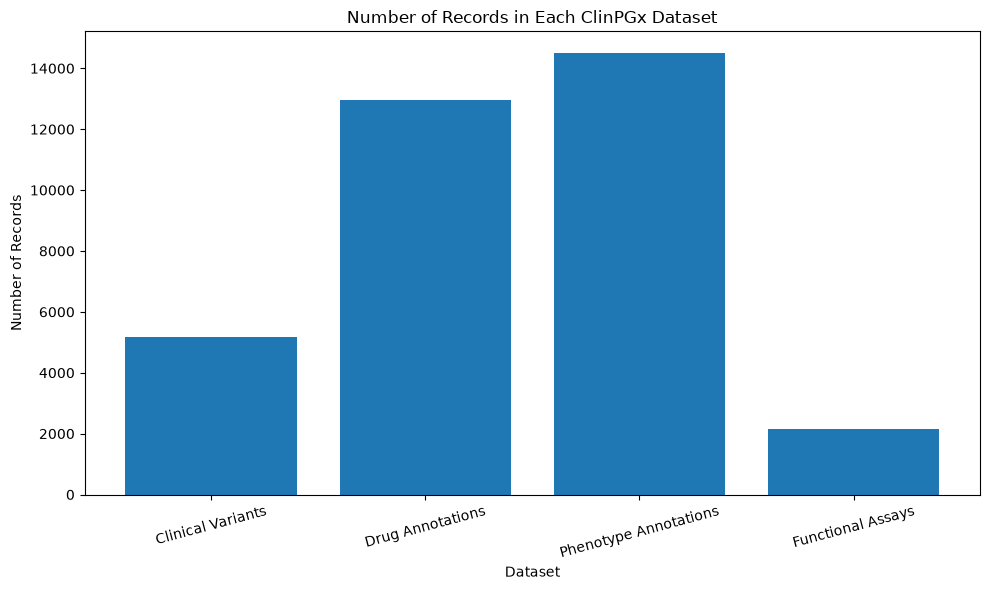

In [224]:
# Create a dictionary containing the number of rows in each dataset.
dataset_sizes = {
    "Clinical Variants": len(clinical),
    "Drug Annotations": len(drug),
    "Phenotype Annotations": len(phenotype),
    "Functional Assays": len(functional)
}
# Create a bar chart comparing the sizes of the datasets.
plt.figure(figsize=(10,6))
plt.bar(dataset_sizes.keys(), dataset_sizes.values())
plt.title("Number of Records in Each ClinPGx Dataset")
plt.xlabel("Dataset")
plt.ylabel("Number of Records")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Observations
The four ClinPGx datasets differ substantially in size. The Variant Phenotype Annotation dataset contains the largest number of records, followed by the Variant Drug Annotation dataset. The Clinical Variants dataset is considerably smaller, while the Functional Assay dataset contains the fewest records. This distribution indicates that ClinPGx places greater emphasis on collecting clinical and phenotype annotation evidence than laboratory functional assay data.

#### Implications
The larger annotation datasets are expected to provide the majority of the predictive information during feature engineering, while the smaller Functional Assay dataset may contribute specialized biological evidence for a subset of gene–drug relationships. Because the Functional Assay dataset contains relatively few records, it may not align with every observation in the larger datasets during data integration. Careful merging will be necessary to preserve useful experimental evidence without unnecessarily reducing the size of the final master dataset.

#### Reasoning
Missing values can influence both data integration and model performance. Identifying incomplete fields early allows potential challenges to be documented before any preprocessing begins.

#### Expectations
Because the Clinical Variants dataset is highly curated, relatively few missing values are expected. Any missing values are anticipated to occur primarily in optional descriptive fields rather than essential identifiers.

#### Influence on the Project
This analysis will identify columns that may require cleaning, exclusion, or special handling during feature engineering.

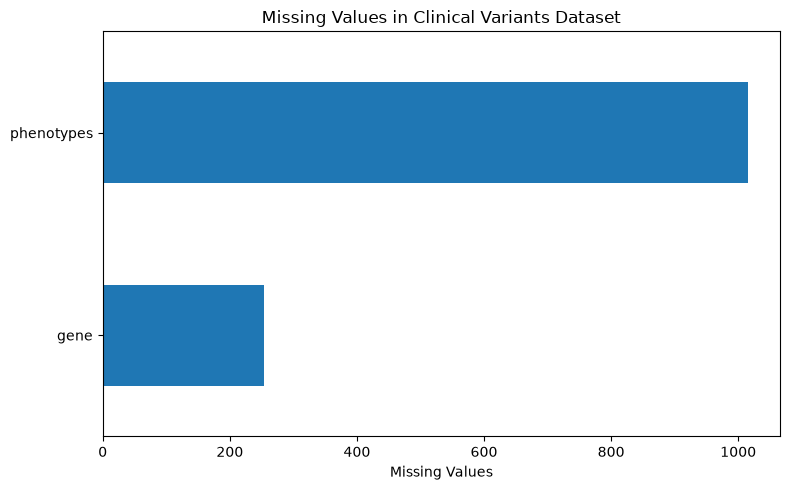

In [225]:
missing = clinical.isnull().sum()
missing = missing[missing > 0]
missing.sort_values().plot.barh(figsize=(8,5))
plt.title("Missing Values in Clinical Variants Dataset")
plt.xlabel("Missing Values")
plt.tight_layout()
plt.show()

#### Observations
Most missing values occur in the phenotype field, while only a small number occur in the primary biological identifiers. Overall, the dataset appears relatively complete compared to the other ClinPGx resources.

#### Implications
The high completeness of the key identifiers suggests that this dataset should integrate well with the other ClinPGx datasets. Missing phenotype information may reduce the usefulness of that variable as a predictive feature unless appropriate handling strategies are applied.

#### Reasoning
The Variant Drug Annotation dataset contains substantially more descriptive variables than the Clinical Variants dataset. Examining missing values helps distinguish between core biological information and optional study-specific metadata.

#### Expectations
Most missing values are expected to occur in optional annotation fields describing study populations, metabolizer classifications, or complex drug interactions.

#### Influence on the Project
This analysis will guide decisions regarding which variables should be retained, transformed, or excluded during data cleaning.

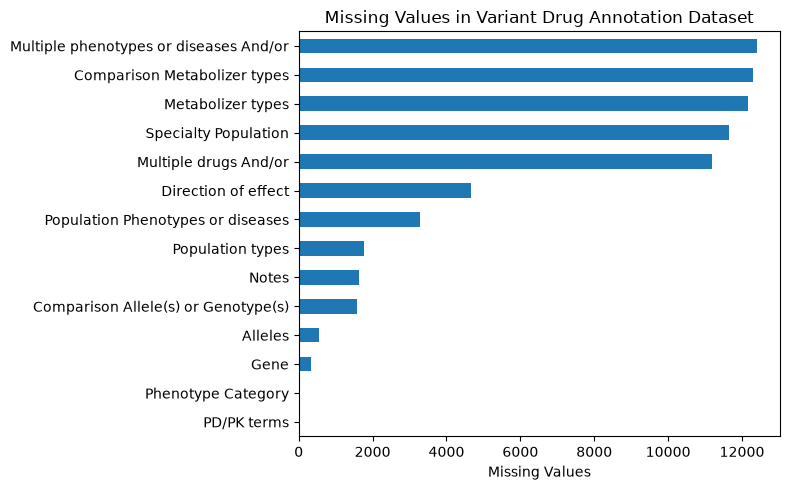

In [226]:
missing = drug.isnull().sum()
missing = missing[missing > 0]
missing.sort_values().plot.barh(figsize=(8,5))
plt.title("Missing Values in Variant Drug Annotation Dataset")
plt.xlabel("Missing Values")
plt.tight_layout()
plt.show()

#### Observations
The majority of missing values occur in optional annotation fields rather than in the core biological identifiers. Many of these variables appear applicable only to specific pharmacogenomic studies.

#### Implications
The observed missingness appears systematic rather than random, suggesting that these fields should be evaluated individually instead of being removed solely because of their incompleteness.

#### Reasoning
The Variant Phenotype Annotation dataset contains the largest number of records. Understanding its completeness is essential because it may become a major contributor to the final feature set.

#### Expectations
Given the diversity of phenotype studies, substantial missing values are expected within optional clinical descriptors while the primary identifiers should remain largely complete.

#### Influence on the Project
The results will inform later decisions regarding feature selection and missing-value handling strategies.

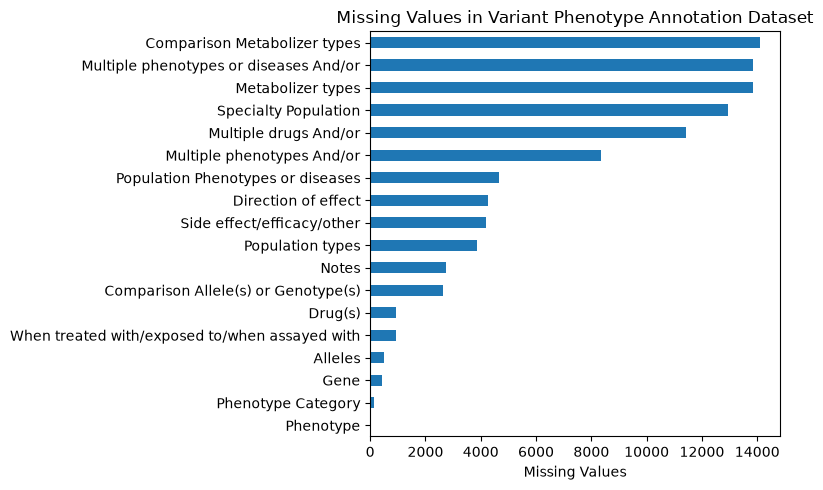

In [227]:
missing = phenotype.isnull().sum()
missing = missing[missing > 0]
missing.sort_values().plot.barh(figsize=(8,5))
plt.title("Missing Values in Variant Phenotype Annotation Dataset")
plt.xlabel("Missing Values")
plt.tight_layout()
plt.show()

### Observations
The largest concentrations of missing values occur in variables describing specialty populations, metabolizer comparisons, and multiple-phenotype or multiple-drug scenarios. Core biological information appears substantially more complete.

### Implications
These findings suggest that most missing values reflect study design differences rather than poor data quality. Variables with extensive missingness should be evaluated for biological importance before determining whether they are suitable predictive features.

#### Reasoning
The Functional Assay dataset contributes experimental evidence rather than clinical observations. Assessing its completeness provides insight into the reliability of potential functional features.

#### Expectations
Experimental metadata such as assay conditions and cell types are expected to contain more missing values than the primary biological identifiers.

#### Influence on the Project
This analysis will determine whether functional assay variables should be incorporated into the machine learning feature set.

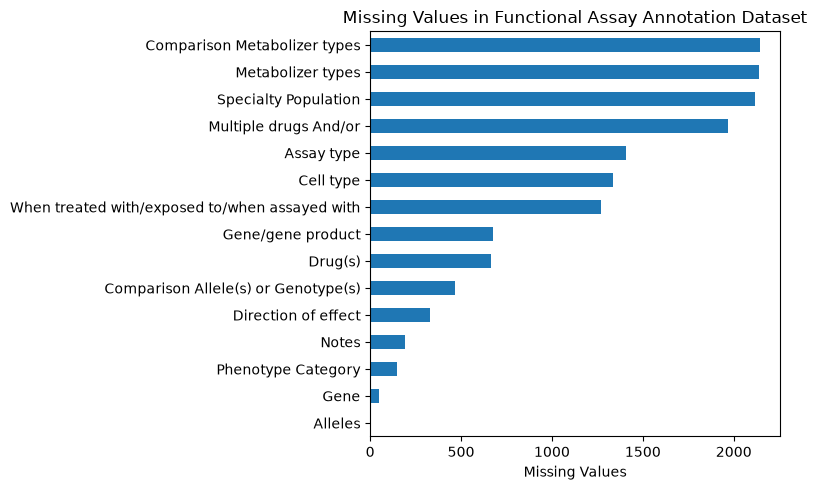

In [228]:
missing = functional.isnull().sum()
missing = missing[missing > 0]
missing.sort_values().plot.barh(figsize=(8,5))
plt.title("Missing Values in Functional Assay Annotation Dataset")
plt.xlabel("Missing Values")
plt.tight_layout()
plt.show()

#### Observations
Missing values are concentrated in experimental metadata, including assay type, cell type, metabolizer classifications, and specialty populations while the primary biological information remains comparatively complete.

#### Implications
Although these variables may provide valuable biological context, their incompleteness suggests that they should be incorporated selectively rather than treated as essential model inputs.

#### Reasoning
Identifying the most frequently occurring genes provides insight into the biological focus of the ClinPGx datasets and highlights which pharmacogenes contribute most of the available evidence.

#### Expectations
Genes involved in drug metabolism are expected to dominate the dataset because they have been studied extensively in pharmacogenomics.

#### Influence on the Project
Understanding gene frequencies will aid feature engineering and help identify potential class imbalance during model development.

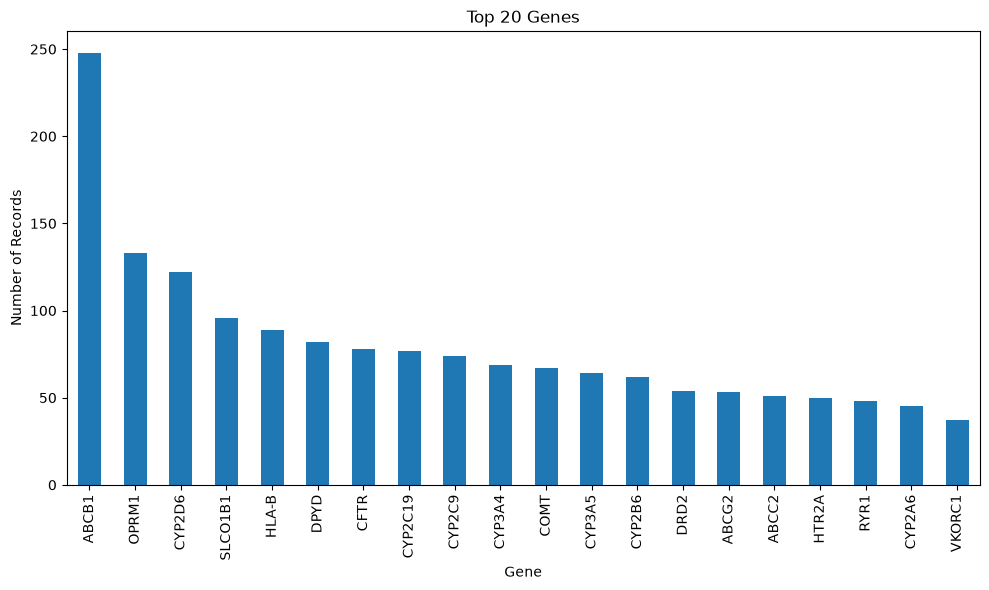

In [229]:
clinical["gene"].value_counts().head(20).plot.bar(figsize=(10,6))
plt.title("Top 20 Genes")
plt.xlabel("Gene")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Observations
A relatively small number of genes account for a substantial proportion of the records, indicating that pharmacogenomic research is concentrated on clinically important pharmacogenes.

#### Implications
The model may naturally receive more training examples for these frequently studied genes. This imbalance should be considered when evaluating model performance and generalizability.

#### Reasoning
Drug frequency provides insight into which medications have the strongest evidence base within the ClinPGx datasets.

#### Expectations
Commonly prescribed medications with established pharmacogenomic guidelines are expected to appear most frequently.

#### Influence on the Project
This analysis will help characterize the distribution of drug-related evidence and identify potential representation imbalances.

/tmp/ipykernel_32207/1488173918.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


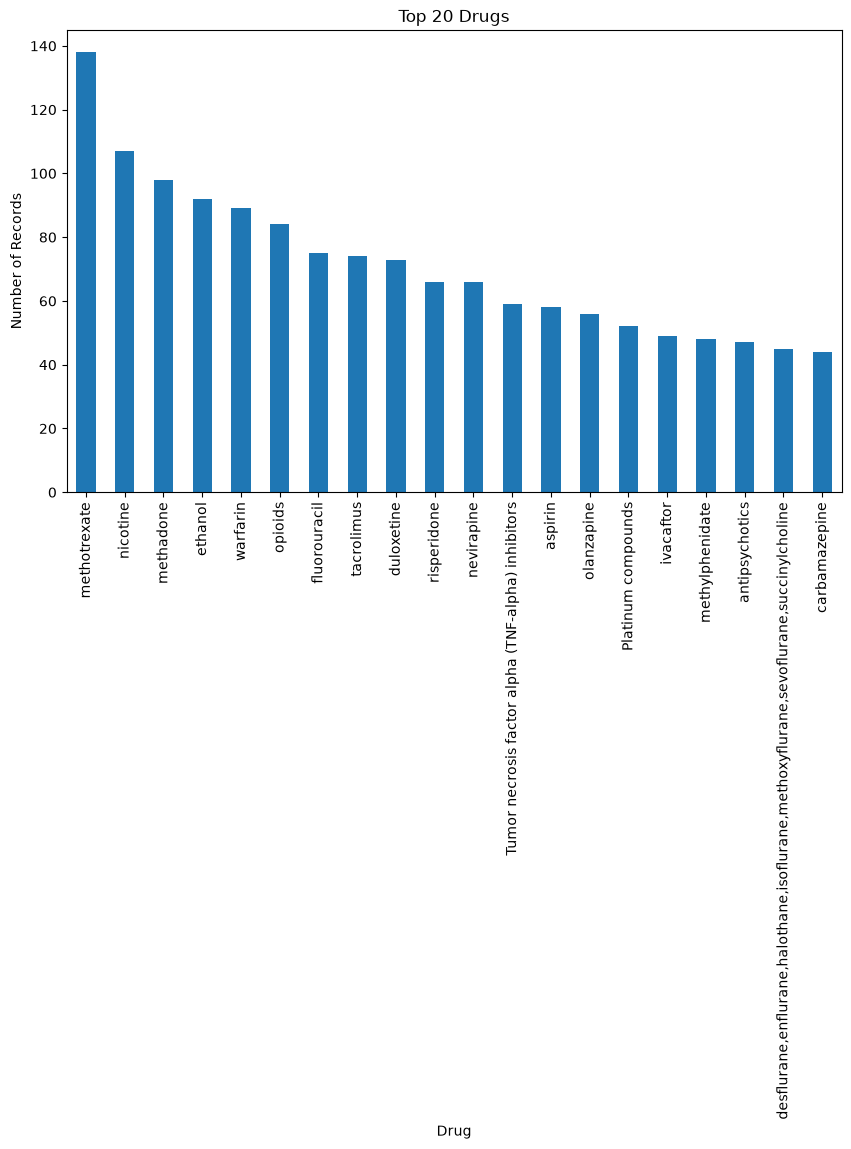

In [230]:
clinical["chemicals"].value_counts().head(20).plot.bar(figsize=(10,6))
plt.title("Top 20 Drugs")
plt.xlabel("Drug")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Observations
Methotrexate is the most frequently represented drug in the Clinical Variants dataset, followed by nicotine, methadone, ethanol, and warfarin. The remaining medications show a gradual decrease in frequency rather than an abrupt drop, indicating that pharmacogenomic evidence is distributed across a diverse set of clinically relevant drugs. Many of the most frequently represented medications are associated with therapeutic areas where genetic variation is known to influence drug efficacy, toxicity, or dosing, reflecting major areas of pharmacogenomic research.

#### Implications
The distribution suggests that the machine learning model will have more training examples for certain medications than for others, which may improve predictive performance for well-represented drugs while limiting generalization for drugs with fewer observations. The presence of a broad range of frequently studied medications also supports the decision to combine multiple ClinPGx datasets into a unified master dataset. Integrating complementary evidence from drug annotations, phenotype annotations, and functional assays should provide richer biological context for these clinically important gene–drug relationships.

### Additional Observation
The appearance of nicotine and ethanol among the most frequently represented chemicals indicates that the dataset includes clinically relevant chemical exposures in addition to prescription medications. Consequently, the machine learning model should be interpreted as predicting pharmacogenomic relationships for chemicals broadly defined rather than exclusively for prescription drugs.

### Reasoning
Evidence levels indicate the strength of scientific support behind each clinical relationship. Understanding their distribution provides insight into the overall quality of the training data.

### Expectations
Because the Clinical Variants dataset contains clinically curated pharmacogenomic relationships, a range of evidence levels is expected to be represented. While higher evidence levels may be prominent, lower levels are also anticipated because pharmacogenomic knowledge continues to evolve as new research emerges.

### Influence on the Project
Examining the distribution of evidence levels will help assess the overall strength of the available clinical evidence and determine whether evidence level should be incorporated as a feature or used to evaluate confidence in model predictions.

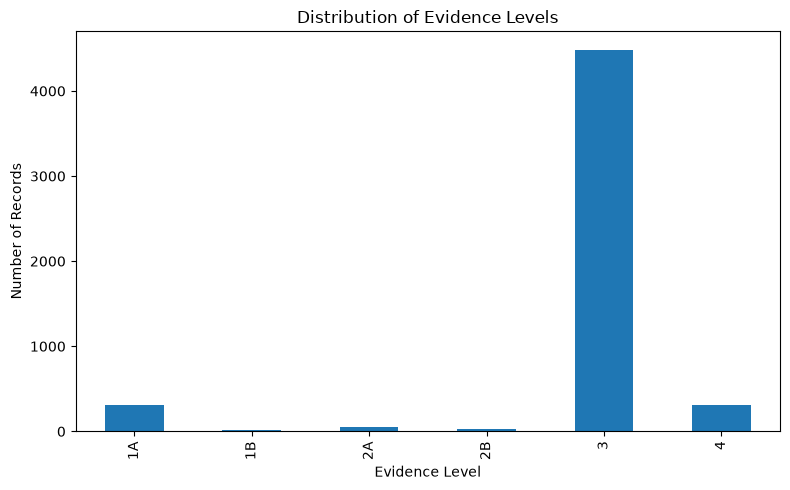

In [231]:
clinical["level of evidence"].value_counts().sort_index().plot.bar(figsize=(8,5))
plt.title("Distribution of Evidence Levels")
plt.xlabel("Evidence Level")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

#### Observations
Evidence Level 3 is the most frequently represented category by a substantial margin, while the remaining evidence levels occur much less frequently. This indicates that a large proportion of the ClinPGx Clinical Variants dataset consists of pharmacogenomic relationships supported by moderate levels of clinical evidence rather than the highest levels of validation. The presence of records across multiple evidence levels demonstrates that the dataset captures pharmacogenomic knowledge at varying stages of clinical maturity.

#### Implications
Because Evidence Level 3 dominates the dataset, the machine learning model will be trained primarily on relationships supported by moderate clinical evidence. Consequently, the model should be interpreted as learning patterns from the currently available pharmacogenomic literature rather than exclusively from the strongest clinical recommendations. Evidence level may also serve as a valuable feature or confidence indicator during model development, allowing future predictions to be interpreted alongside the strength of the supporting scientific evidence.

#### Reasoning
Duplicate records can influence dataset size, feature distributions, and model training. Before removing any records, it is important to determine the extent of duplication within each dataset.

#### Expectations
Some duplicate records are expected because multiple publications may describe the same gene–drug relationship.

#### Influence on the Project
The results will inform whether duplicate records should be aggregated or otherwise handled during data integration.

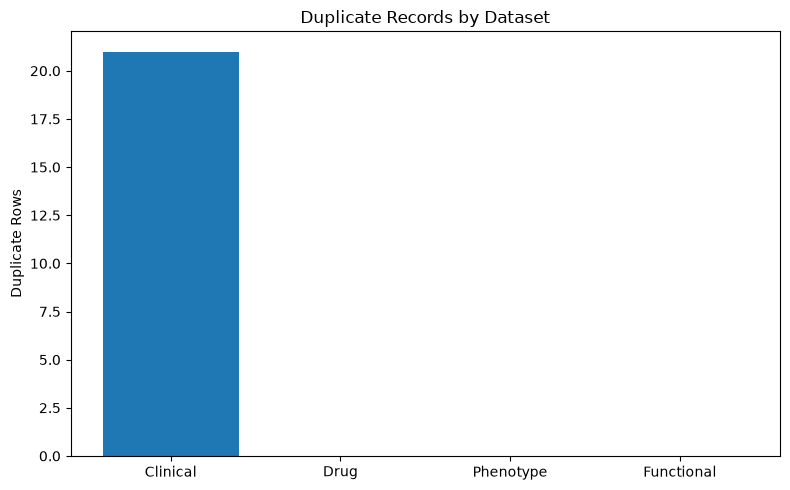

In [232]:
duplicates = {
    "Clinical": clinical.duplicated().sum(),
    "Drug": drug.duplicated().sum(),
    "Phenotype": phenotype.duplicated().sum(),
    "Functional": functional.duplicated().sum()
}
plt.figure(figsize=(8,5))
plt.bar(duplicates.keys(), duplicates.values())
plt.title("Duplicate Records by Dataset")
plt.ylabel("Duplicate Rows")
plt.tight_layout()
plt.show()

In [233]:
# Count repeated Gene–Variant–Chemical relationships.
clinical.duplicated(subset=["gene", "variant", "chemicals"]).sum()

np.int64(371)

#### Observations
The Clinical Variants dataset contains 20 exact duplicate rows, whereas no exact duplicate rows were identified in the Variant Drug Annotation, Variant Phenotype Annotation, or Functional Assay datasets. This result was somewhat unexpected given the substantially larger size of the annotation datasets. One possible explanation is that the annotation datasets contain repeated biological relationships that differ in at least one descriptive field, preventing them from being classified as exact duplicates.

#### Implications
At this stage, the duplicate counts should be interpreted cautiously. The current analysis identifies only exact row duplication and does not determine whether multiple records represent the same underlying gene–drug relationship. During Notebook 02 (Data Cleaning), duplicate records will be investigated further to determine whether they represent data-entry redundancy or distinct pieces of scientific evidence. Any decisions regarding duplicate removal or aggregation will be based on the biological meaning of the records rather than duplicate counts alone.

#### Visualization 10

##### Reasoning
Evaluating column completeness provides a more intuitive measure of data quality than missing-value counts alone and helps identify variables that may be suitable predictive features.

##### Expectation
Core biological identifiers are expected to demonstrate high completeness, while optional annotation fields are expected to be less complete.

##### Influence on the Project
This analysis will support feature selection by identifying variables that contain sufficient information for reliable machine learning.

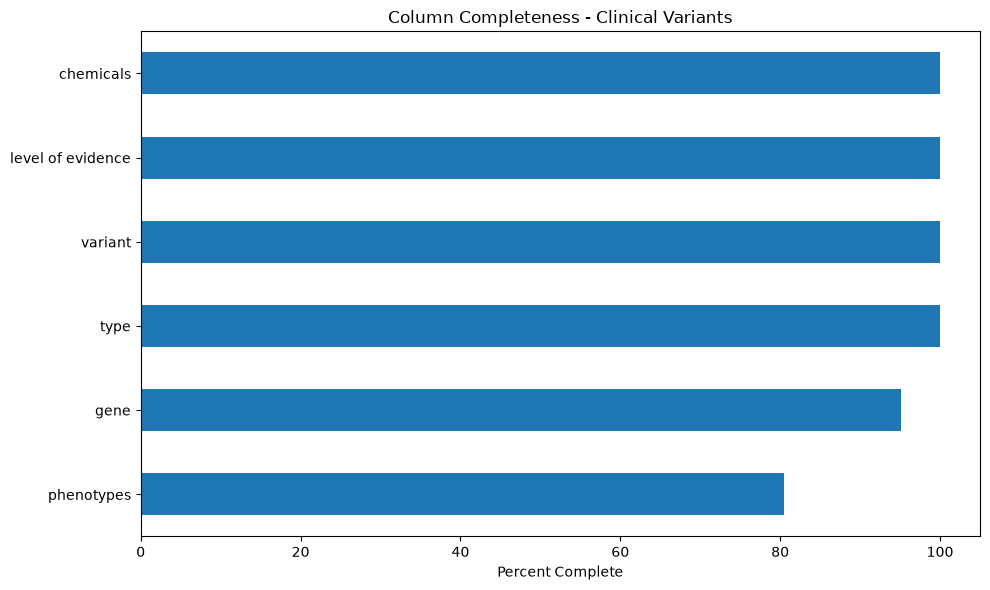

In [234]:
completeness = (
    clinical.notnull().mean()*100
).sort_values()
completeness.plot.barh(figsize=(10,6))
plt.title("Column Completeness - Clinical Variants")
plt.xlabel("Percent Complete")
plt.tight_layout()
plt.show()

##### Observations
The highest completeness is observed in the primary biological identifiers, whereas optional study-specific variables exhibit substantially lower completeness.

##### Implications
These findings support prioritizing highly complete biological variables during feature engineering while evaluating incomplete annotation fields individually based on their biological relevance rather than excluding them solely because of missing values.

#### Next Step
The findings from these visualizations will be incorporated into Notebook 02 (Data Cleaning) when developing the preprocessing pipeline.

### 14. Questions for Future Investigation

While exploring the data, several questions emerged:
1. Which columns uniquely identify a gene-drug relationship?
2. How should repeated studies be aggregated?
3. Are phenotype descriptions standardized?
4. Should functional assay data become predictive features?
5. How should conflicting annotations be handled?
6. If at all, how should varying notations be handled?

### 15. Conclusions

This exploratory analysis established a foundational understanding of the four ClinPGx datasets without modifying the original data.

Several important findings emerged:
- The four datasets represent complementary views of pharmacogenomic knowledge rather than independent machine learning datasets.
- Gene, variant (or haplotype), and drug identifiers appear to be the strongest candidates for constructing a unified master dataset.
- Each dataset contributes different types of biological and clinical information, suggesting that data integration will produce a substantially richer feature set than any individual dataset alone.
- Missing values, repeated observations, and inconsistent formatting are expected challenges that must be addressed systematically during data cleaning.
- The exploratory analysis also highlighted the importance of documenting every transformation to ensure that the final machine learning pipeline is reproducible and scientifically defensible.

The next phase of the project will focus on developing a formal data-cleaning and integration strategy based on these observations.
